tau       Quad_NLL     Sim_NLL      |Diff|
------------------------------------------
0.9       6.005424    6.022336    0.016913
1.0       6.271099    6.290410    0.019311
1.1       6.497408    6.545894    0.048485
1.2       6.692170    6.715483    0.023314
1.3       6.861365    6.897805    0.036440
1.4       7.009607    7.047017    0.037411
1.5       7.140493    7.148554    0.008060


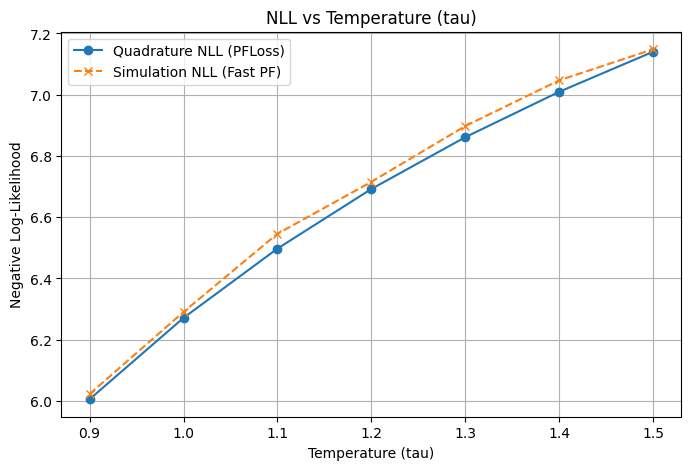

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class PFLoss(nn.Module):
    def __init__(self, tau: float, K: int = 64):
        super().__init__()
        u, w = np.polynomial.legendre.leggauss(K)
        u = 0.5 * (u + 1.0)
        w = 0.5 * w
        self.register_buffer("u", torch.tensor(u, dtype=torch.float64))
        self.register_buffer("logu", torch.tensor(np.log(u), dtype=torch.float64))
        self.register_buffer("logw", torch.tensor(np.log(w), dtype=torch.float64))
        self.tau = tau

    def forward(self, logits, target):
        logits = logits.double()
        v_max, _ = logits.max(dim=-1, keepdim=True)
        log_p = (logits - v_max) / self.tau
        log_pu = log_p.unsqueeze(-1) + self.logu.view(1, 1, -1)
        log_term = torch.where(
            log_pu < -0.6931,
            torch.log1p(-log_pu.exp()),
            torch.log(-torch.expm1(log_pu)),
        )
        B, V = logits.shape
        mask = torch.ones_like(logits).scatter_(1, target.unsqueeze(1), 0.0)
        inner = (log_term * mask.unsqueeze(-1)).sum(dim=1)
        log_int = torch.logsumexp(self.logw + inner, dim=-1)
        v_y = logits.gather(1, target.unsqueeze(1)).squeeze(1)
        loss = -((v_y - v_max.squeeze(-1)) / self.tau) - log_int
        return loss.float().mean()

def permute_and_flip_nll_fast(logits_1d, target, tau, n_samples=500_000, seed=0):
    rng = np.random.default_rng(seed)
    v = logits_1d.detach().cpu().numpy().astype(np.float64).ravel()
    V = v.shape[0]
    y = int(target.item()) if hasattr(target, "item") else int(target)

    count = 0
    chunk = 10_000
    for start in range(0, n_samples, chunk):
        m = min(chunk, n_samples - start)
        noise = rng.exponential(scale=tau, size=(m, V))
        winners = np.argmax(v[None, :] + noise, axis=1)
        count += int((winners == y).sum())

    p_hat = count / n_samples
    nll = -np.log(max(p_hat, 1e-12))
    if 0 < p_hat < 1:
        nll_se = 1.96 / np.sqrt(n_samples * p_hat * (1 - p_hat))
    else:
        nll_se = float("inf")
    return nll, p_hat, nll_se

torch.manual_seed(42)
V = 10000
logits = torch.randn(1, V)
target = logits.squeeze(0).topk(3).indices[1:2] 

taus = [0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
nll_quad_list = []
nll_sim_list = []

print(f"{'tau':<6}{'Quad_NLL':>12}{'Sim_NLL':>12}{'|Diff|':>12}")
print("-" * 42)

for tau in taus:
    loss_fn = PFLoss(tau=tau, K=64)
    nll_quad = loss_fn(logits, target).item()
    nll_sim, _, _ = permute_and_flip_nll_fast(logits.squeeze(0), target, tau)
    
    nll_quad_list.append(nll_quad)
    nll_sim_list.append(nll_sim)
    
    diff = abs(nll_quad - nll_sim)
    print(f"{tau:<6.1f}{nll_quad:>12.6f}{nll_sim:>12.6f}{diff:>12.6f}")

plt.figure(figsize=(8, 5))
plt.plot(taus, nll_quad_list, marker='o', label='Quadrature NLL (PFLoss)')
plt.plot(taus, nll_sim_list, marker='x', linestyle='--', label='Simulation NLL (Fast PF)')
plt.xlabel('Temperature (tau)')
plt.ylabel('Negative Log-Likelihood')
plt.title('NLL vs Temperature (tau)')
plt.legend()
plt.grid(True)
plt.savefig('nll_vs_tau.png')
plt.show()

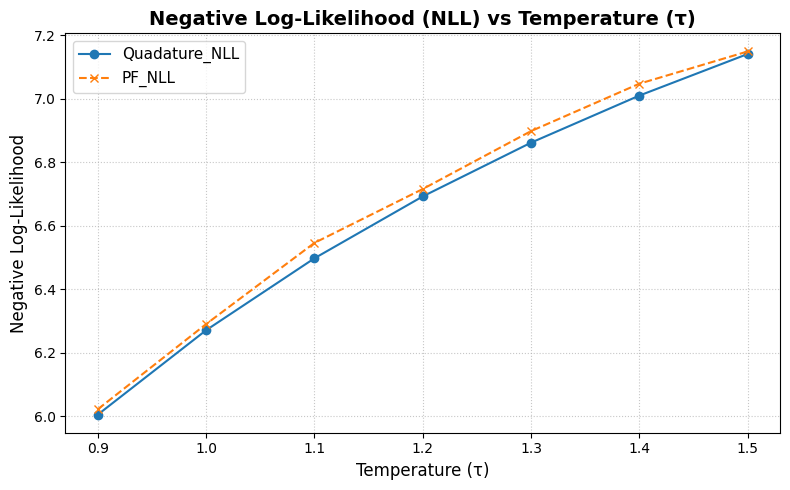

In [2]:
import matplotlib.pyplot as plt

# Data from the generated table
tau = [0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
quad_nll = [6.005424, 6.271099, 6.497408, 6.692170, 6.861365, 7.009607, 7.140493]
sim_nll = [6.022336, 6.290410, 6.545894, 6.715483, 6.897805, 7.047017, 7.148554]

# Initialize the plot
plt.figure(figsize=(8, 5))

# Plot both NLL values
plt.plot(
    tau, 
    quad_nll, 
    marker="o", 
    linestyle="-", 
    color="#1f77b4", 
    label="Quadature_NLL"
)
plt.plot(
    tau, 
    sim_nll, 
    marker="x", 
    linestyle="--", 
    color="#ff7f0e", 
    label="PF_NLL"
)

# Apply formatting and labels
plt.title("Negative Log-Likelihood (NLL) vs Temperature (τ)", fontsize=14, fontweight="bold")
plt.xlabel("Temperature (τ)", fontsize=12)
plt.ylabel("Negative Log-Likelihood", fontsize=12)
plt.legend(loc="upper left", frameon=True, fontsize=11)

# Add a grid for readability
plt.grid(True, linestyle=":", alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [4]:
class PFLossF64(nn.Module):
    """Same as PFLoss but stays in float64 — for gradient checking only."""
    def __init__(self, tau: float, K: int = 64):
        super().__init__()
        u, w = np.polynomial.legendre.leggauss(K)
        u = 0.5 * (u + 1.0)
        w = 0.5 * w
        self.register_buffer("u", torch.tensor(u, dtype=torch.float64))
        self.register_buffer("logu", torch.tensor(np.log(u), dtype=torch.float64))
        self.register_buffer("logw", torch.tensor(np.log(w), dtype=torch.float64))
        self.tau = tau

    def forward(self, logits, target):
        logits = logits.double()
        v_max, _ = logits.max(dim=-1, keepdim=True)
        log_p = (logits - v_max) / self.tau
        log_pu = log_p.unsqueeze(-1) + self.logu.view(1, 1, -1)
        log_term = torch.where(
            log_pu < -0.6931,
            torch.log1p(-log_pu.exp()),
            torch.log(-torch.expm1(log_pu)),
        )
        B, V = logits.shape
        mask = torch.ones_like(logits).scatter_(1, target.unsqueeze(1), 0.0)
        inner = (log_term * mask.unsqueeze(-1)).sum(dim=1)
        log_int = torch.logsumexp(self.logw + inner, dim=-1)
        v_y = logits.gather(1, target.unsqueeze(1)).squeeze(1)
        loss = -((v_y - v_max.squeeze(-1)) / self.tau) - log_int
        return loss.mean()  # NO .float() cast — stays float64


# Gradient check
V_small = 100
logits_check = torch.randn(1, V_small, dtype=torch.float64, requires_grad=True)
target_check = torch.tensor([7])
pf_check = PFLossF64(tau=1.0, K=64)

passed = torch.autograd.gradcheck(
    lambda v: pf_check(v, target_check),
    logits_check,
    eps=1e-6,
    atol=1e-4,
    rtol=1e-3,
)
print(f"Numerical gradient check passed: {passed}")

Numerical gradient check passed: True
